RGB shape: (512, 512, 3)
NIR shape: (512, 512)


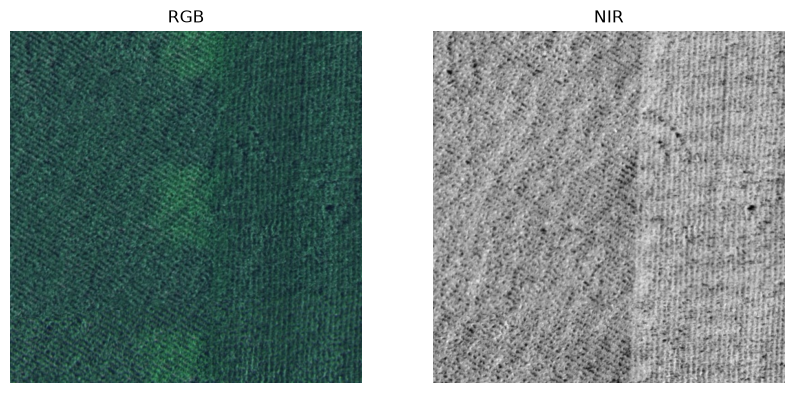

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

rgb_path = "data2019_miniscale/field_images/rgb/1494VZHI1_3709-4157-4221-4669.jpg"
nir_path = "data2019_miniscale/field_images/nir/1494VZHI1_3709-4157-4221-4669.jpg"

rgb = cv2.imread(rgb_path)
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

print("RGB shape:", rgb.shape)
print("NIR shape:", nir.shape)

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(rgb)
axes[0].set_title("RGB")
axes[0].axis('off')
axes[1].imshow(nir, cmap='gray')
axes[1].set_title("NIR")
axes[1].axis('off')
plt.show()

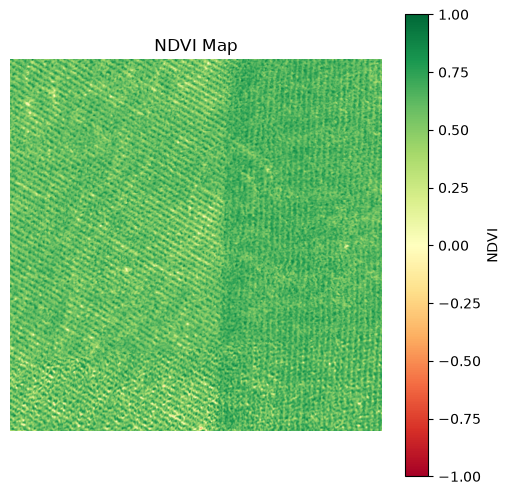

In [2]:
red = rgb[:,:,0].astype(float)
nir_f = nir.astype(float)

ndvi = (nir_f - red) / (nir_f + red + 1e-6)

plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('NDVI Map')
plt.axis('off')
plt.show()

In [3]:
import os

rgb_files = os.listdir("data2019_miniscale/field_images/rgb")
print(rgb_files[50:60])  # peek at some other filenames


['17FCUVCMI_3895-2473-4407-2985.jpg', '17FCUVCMI_616-8201-1128-8713.jpg', '18LX92KA3_10092-10240-10604-10752.jpg', '18LX92KA3_10244-2765-10756-3277.jpg', '18LX92KA3_10244-3277-10756-3789.jpg', '18LX92KA3_10244-6349-10756-6861.jpg', '18LX92KA3_10297-6719-10809-7231.jpg', '18LX92KA3_1040-21562-1552-22074.jpg', '18LX92KA3_10604-10240-11116-10752.jpg', '18LX92KA3_10604-9728-11116-10240.jpg']


In [4]:
print("Red channel - min:", red.min(), "max:", red.max(), "mean:", red.mean())
print("NIR - min:", nir_f.min(), "max:", nir_f.max(), "mean:", nir_f.mean())

Red channel - min: 2.0 max: 119.0 mean: 38.87303161621094
NIR - min: 16.0 max: 252.0 mean: 155.9083709716797


In [31]:
import os
import cv2
import numpy as np

rgb_dir = "data2019_miniscale/field_images/rgb"
nir_dir = "data2019_miniscale/field_images/nir"

files = os.listdir(rgb_dir)[:200]  # scan first 200 images
best_file = None
best_ndvi_mean = -999

for f in files:
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)
    if rgb_img is None or nir_img is None:
        continue
    red_ch = rgb_img[:,:,2].astype(float)  # BGR order, so index 2 is Red
    nir_ch = nir_img.astype(float)
    ndvi = (nir_ch - red_ch) / (nir_ch + red_ch + 1e-6)
    m = ndvi.mean()
    if m > best_ndvi_mean:
        best_ndvi_mean = m
        best_file = f

print("Most vegetated image found:", best_file)
print("Its average NDVI:", best_ndvi_mean)

Most vegetated image found: 3CPYLP42D_2502-2074-3014-2586.jpg
Its average NDVI: 0.6937780454300837


In [32]:
import os
import cv2
import numpy as np
import pandas as pd

rgb_dir = "data2019_miniscale/field_images/rgb"
nir_dir = "data2019_miniscale/field_images/nir"

def classify_health(ndvi_mean):
    if ndvi_mean >= 0.4:
        return "Healthy"
    elif ndvi_mean >= 0.15:
        return "Moderate"
    else:
        return "Stressed"

files = os.listdir(rgb_dir)[:3000]  # scan first 200 images
results = []

for f in files:
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)
    if rgb_img is None or nir_img is None:
        continue
    red_ch = rgb_img[:,:,2].astype(float)
    nir_ch = nir_img.astype(float)
    ndvi = (nir_ch - red_ch) / (nir_ch + red_ch + 1e-6)
    ndvi_mean = ndvi.mean()
    results.append({
        "filename": f,
        "ndvi_mean": round(ndvi_mean, 3),
        "health_status": classify_health(ndvi_mean)
    })

df = pd.DataFrame(results)
print(df["health_status"].value_counts())
df.head(10)

health_status
Stressed    2316
Moderate     367
Healthy      317
Name: count, dtype: int64


,filename,ndvi_mean,health_status
0,1238UQC9Y_4084-1739-4596-2251.jpg,-0.326,Stressed
1,1238UQC9Y_4084-2251-4596-2763.jpg,-0.303,Stressed
2,1238UQC9Y_4505-527-5017-1039.jpg,-0.109,Stressed
3,1238UQC9Y_4596-1739-5108-2251.jpg,-0.327,Stressed
4,1238UQC9Y_4596-2251-5108-2763.jpg,-0.329,Stressed
5,1238UQC9Y_4889-4243-5401-4755.jpg,-0.273,Stressed
6,1238UQC9Y_5108-1739-5620-2251.jpg,-0.275,Stressed
7,1238UQC9Y_5108-2251-5620-2763.jpg,-0.292,Stressed
8,1238UQC9Y_5401-4243-5913-4755.jpg,-0.290,Stressed
9,12JFH6CLF_3424-4138-3936-4650.jpg,0.446,Healthy


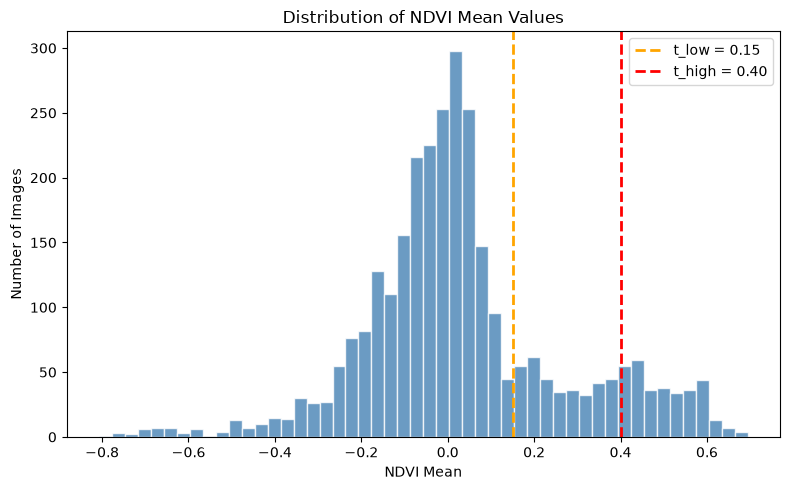

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(df["ndvi_mean"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(0.15, color="orange", linestyle="--", linewidth=2, label="t_low = 0.15")
plt.axvline(0.40, color="red", linestyle="--", linewidth=2, label="t_high = 0.40")
plt.xlabel("NDVI Mean")
plt.ylabel("Number of Images")
plt.title("Distribution of NDVI Mean Values")
plt.legend()
plt.tight_layout()
plt.savefig("ndvi_distribution.png", dpi=150)
plt.show()

In [7]:
print(df.columns.tolist())

['filename', 'ndvi_mean', 'health_status']


In [8]:
print(df["health_status"].unique())

<ArrowStringArray>
['Stressed', 'Healthy', 'Moderate']
Length: 3, dtype: str


    t_low  t_high  macro_f1
6    0.15    0.35  1.000000
7    0.15    0.40  1.000000
5    0.15    0.30  0.968511
1    0.10    0.35  0.921836
2    0.10    0.40  0.921836
11   0.20    0.35  0.906088
12   0.20    0.40  0.906088
8    0.15    0.45  0.900285
0    0.10    0.30  0.892023
9    0.15    0.50  0.860000

Best thresholds: t_low=0.15, t_high=0.35 (macro F1=1.000)
Your current thresholds (t_low=0.15, t_high=0.40) macro F1: 1.000


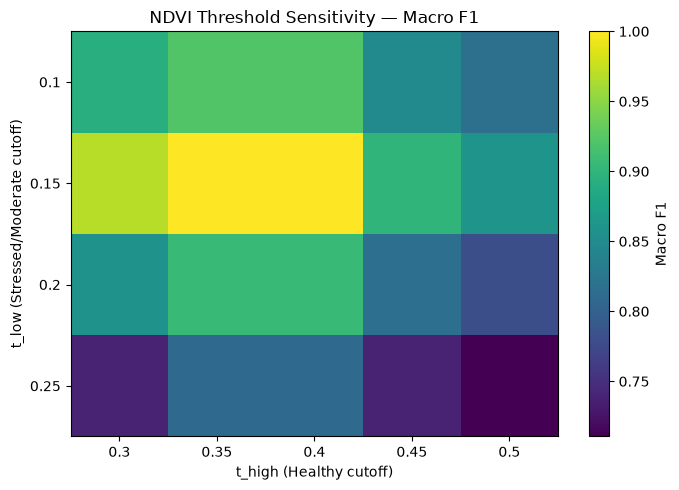

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

ndvi_values = df["ndvi_mean"]
true_labels = df["health_status"]

def classify(ndvi, t_low, t_high):
    if ndvi >= t_high:
        return "Healthy"
    elif ndvi >= t_low:
        return "Moderate"
    else:
        return "Stressed"

low_candidates = [0.10, 0.15, 0.20, 0.25]
high_candidates = [0.30, 0.35, 0.40, 0.45, 0.50]

results = []
for t_low in low_candidates:
    for t_high in high_candidates:
        if t_low >= t_high:
            continue
        predicted = ndvi_values.apply(lambda x: classify(x, t_low, t_high))
        f1 = f1_score(true_labels, predicted, average="macro")
        results.append({"t_low": t_low, "t_high": t_high, "macro_f1": f1})

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print(results_df.head(10))

best = results_df.iloc[0]
print(f"\nBest thresholds: t_low={best['t_low']}, t_high={best['t_high']} (macro F1={best['macro_f1']:.3f})")
print(f"Your current thresholds (t_low=0.15, t_high=0.40) macro F1: "
      f"{results_df[(results_df.t_low==0.15) & (results_df.t_high==0.40)]['macro_f1'].values[0]:.3f}")

pivot = results_df.pivot(index="t_low", columns="t_high", values="macro_f1")
plt.figure(figsize=(7, 5))
plt.imshow(pivot, cmap="viridis", aspect="auto")
plt.colorbar(label="Macro F1")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("t_high (Healthy cutoff)")
plt.ylabel("t_low (Stressed/Moderate cutoff)")
plt.title("NDVI Threshold Sensitivity — Macro F1")
plt.tight_layout()
plt.savefig("ndvi_threshold_sensitivity.png", dpi=150)
plt.show()

In [10]:
def classify_soil(ndwi_mean, brightness_mean):
    if ndwi_mean > 0.1:
        return "Moist/Wet"
    elif brightness_mean > 150 and ndwi_mean < -0.1:
        return "Dry/Bare"
    else:
        return "Normal"

results_soil = []

for f in files:
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)
    if rgb_img is None or nir_img is None:
        continue
    green_ch = rgb_img[:,:,1].astype(float)  # BGR order, Green is index 1
    nir_ch = nir_img.astype(float)
    ndwi = (green_ch - nir_ch) / (green_ch + nir_ch + 1e-6)
    brightness = rgb_img.astype(float).mean()
    results_soil.append({
        "filename": f,
        "ndwi_mean": round(ndwi.mean(), 3),
        "brightness": round(brightness, 1),
        "soil_status": classify_soil(ndwi.mean(), brightness)
    })

df_soil = pd.DataFrame(results_soil)
print(df_soil["soil_status"].value_counts())
df_soil.head(10)

soil_status
Moist/Wet    143
Normal        57
Name: count, dtype: int64


,filename,ndwi_mean,brightness,soil_status
0,1238UQC9Y_4084-1739-4596-2251.jpg,0.140,81.3,Moist/Wet
1,1238UQC9Y_4084-2251-4596-2763.jpg,0.179,105.3,Moist/Wet
2,1238UQC9Y_4505-527-5017-1039.jpg,0.082,121.1,Normal
3,1238UQC9Y_4596-1739-5108-2251.jpg,0.135,83.6,Moist/Wet
4,1238UQC9Y_4596-2251-5108-2763.jpg,0.127,81.7,Moist/Wet
5,1238UQC9Y_4889-4243-5401-4755.jpg,0.150,106.9,Moist/Wet
6,1238UQC9Y_5108-1739-5620-2251.jpg,0.128,97.2,Moist/Wet
7,1238UQC9Y_5108-2251-5620-2763.jpg,0.128,95.3,Moist/Wet
8,1238UQC9Y_5401-4243-5913-4755.jpg,0.099,84.9,Normal
9,12JFH6CLF_3424-4138-3936-4650.jpg,-0.189,86.1,Normal


In [11]:
def classify_pest_risk(ndvi_mean, ndvi_std):
    if ndvi_std > 0.15 and ndvi_mean < 0.4:
        return "High Risk"
    elif ndvi_std > 0.08:
        return "Moderate Risk"
    else:
        return "Low Risk"

results_pest = []

for f in files:
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)
    if rgb_img is None or nir_img is None:
        continue
    red_ch = rgb_img[:,:,2].astype(float)
    nir_ch = nir_img.astype(float)
    ndvi = (nir_ch - red_ch) / (nir_ch + red_ch + 1e-6)
    ndvi_mean = ndvi.mean()
    ndvi_std = ndvi.std()  # patchiness/variance signal
    results_pest.append({
        "filename": f,
        "ndvi_mean": round(ndvi_mean, 3),
        "ndvi_std": round(ndvi_std, 3),
        "pest_risk": classify_pest_risk(ndvi_mean, ndvi_std)
    })

df_pest = pd.DataFrame(results_pest)
print(df_pest["pest_risk"].value_counts())
df_pest.head(10)

pest_risk
High Risk        88
Moderate Risk    88
Low Risk         24
Name: count, dtype: int64


,filename,ndvi_mean,ndvi_std,pest_risk
0,1238UQC9Y_4084-1739-4596-2251.jpg,-0.326,0.026,Low Risk
1,1238UQC9Y_4084-2251-4596-2763.jpg,-0.303,0.026,Low Risk
2,1238UQC9Y_4505-527-5017-1039.jpg,-0.109,0.351,High Risk
3,1238UQC9Y_4596-1739-5108-2251.jpg,-0.327,0.018,Low Risk
4,1238UQC9Y_4596-2251-5108-2763.jpg,-0.329,0.020,Low Risk
5,1238UQC9Y_4889-4243-5401-4755.jpg,-0.273,0.023,Low Risk
6,1238UQC9Y_5108-1739-5620-2251.jpg,-0.275,0.112,Moderate Risk
7,1238UQC9Y_5108-2251-5620-2763.jpg,-0.292,0.036,Low Risk
8,1238UQC9Y_5401-4243-5913-4755.jpg,-0.290,0.031,Low Risk
9,12JFH6CLF_3424-4138-3936-4650.jpg,0.446,0.467,Moderate Risk


In [12]:
import os
import cv2
import numpy as np
import pandas as pd

rgb_dir = "data2019_miniscale/field_images/rgb"
nir_dir = "data2019_miniscale/field_images/nir"
label_dir = "data2019_miniscale/field_labels/weed_cluster"

files = os.listdir(rgb_dir)[:1500]

data = []

for f in files:
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)
    label_filename = f.replace(".jpg", ".png")
    label_img = cv2.imread(os.path.join(label_dir, label_filename), cv2.IMREAD_GRAYSCALE)

    if rgb_img is None or nir_img is None or label_img is None:
        continue

    red_ch = rgb_img[:, :, 2].astype(float)
    green_ch = rgb_img[:, :, 1].astype(float)
    nir_ch = nir_img.astype(float)

    ndvi = (nir_ch - red_ch) / (nir_ch + red_ch + 1e-6)
    ndwi = (green_ch - nir_ch) / (green_ch + nir_ch + 1e-6)
    brightness = rgb_img.astype(float).mean()

    has_weed = 1 if np.any(label_img > 0) else 0

    data.append({
        "filename": f,
        "ndvi_mean": ndvi.mean(),
        "ndvi_std": ndvi.std(),
        "ndwi_mean": ndwi.mean(),
        "brightness": brightness,
        "weed_cluster": has_weed
    })

df_ml = pd.DataFrame(data)
print("Total samples:", len(df_ml))
print(df_ml["weed_cluster"].value_counts())
df_ml.head(10)

Total samples: 1500
weed_cluster
0    821
1    679
Name: count, dtype: int64


,filename,ndvi_mean,ndvi_std,ndwi_mean,brightness,weed_cluster
0,1238UQC9Y_4084-1739-4596-2251.jpg,-0.326339,0.026216,0.140457,81.317778,0
1,1238UQC9Y_4084-2251-4596-2763.jpg,-0.303275,0.025889,0.179352,105.289633,0
2,1238UQC9Y_4505-527-5017-1039.jpg,-0.108778,0.350943,0.082327,121.119717,0
3,1238UQC9Y_4596-1739-5108-2251.jpg,-0.326682,0.017567,0.134525,83.565974,0
4,1238UQC9Y_4596-2251-5108-2763.jpg,-0.328647,0.020072,0.127228,81.675902,0
5,1238UQC9Y_4889-4243-5401-4755.jpg,-0.273491,0.023246,0.149565,106.880641,0
6,1238UQC9Y_5108-1739-5620-2251.jpg,-0.274977,0.112415,0.127772,97.160247,0
7,1238UQC9Y_5108-2251-5620-2763.jpg,-0.292183,0.036428,0.128255,95.318652,0
8,1238UQC9Y_5401-4243-5913-4755.jpg,-0.289752,0.031173,0.098551,84.921612,0
9,12JFH6CLF_3424-4138-3936-4650.jpg,0.445835,0.467015,-0.189356,86.130056,0


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_ml[["ndvi_mean", "ndvi_std", "ndwi_mean", "brightness"]]
y = df_ml["weed_cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9266666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93       164
           1       0.89      0.96      0.92       136

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


Confusion Matrix:
 [[147  17]
 [  5 131]]


In [14]:
import joblib
joblib.dump(model, "weed_model.pkl")
print("Model saved!")

Model saved!


In [15]:
import os
import cv2
import numpy as np
import pandas as pd

rgb_dir = "data2019_miniscale/field_images/rgb"
nir_dir = "data2019_miniscale/field_images/nir"
label_dir = "data2019_miniscale/field_labels/weed_cluster"

def extract_features(rgb_img, nir_img):
    red = rgb_img[:, :, 2].astype(float)   # BGR order, Red is index 2
    green = rgb_img[:, :, 1].astype(float)
    nir = nir_img.astype(float)

    ndvi = (nir - red) / (nir + red + 1e-6)
    ndwi = (green - nir) / (green + nir + 1e-6)

    return {
        "ndvi_mean": np.mean(ndvi),
        "ndvi_std": np.std(ndvi),
        "ndvi_median": np.median(ndvi),
        "ndvi_p10": np.percentile(ndvi, 10),
        "ndvi_p25": np.percentile(ndvi, 25),
        "ndvi_p75": np.percentile(ndvi, 75),
        "ndvi_p90": np.percentile(ndvi, 90),
        "ndwi_mean": np.mean(ndwi),
        "ndwi_std": np.std(ndwi),
        "brightness_mean": np.mean(rgb_img),
        "brightness_std": np.std(rgb_img),
    }

files = os.listdir(rgb_dir)[:1500]
data = []

for f in files:
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)
    label_filename = f.replace(".jpg", ".png")
    label_img = cv2.imread(os.path.join(label_dir, label_filename), cv2.IMREAD_GRAYSCALE)

    if rgb_img is None or nir_img is None or label_img is None:
        continue

    feats = extract_features(rgb_img, nir_img)
    feats["filename"] = f
    feats["field_id"] = f.split("_")[0]  # e.g. "1238UQC9Y" from "1238UQC9Y_4084-1739-4596-2251.jpg"
    feats["weed_cluster"] = 1 if np.any(label_img > 0) else 0

    data.append(feats)

df_ml2 = pd.DataFrame(data)
print("Total samples:", len(df_ml2))
print("Unique fields:", df_ml2["field_id"].nunique())
print(df_ml2["weed_cluster"].value_counts())
df_ml2.head(10)

Total samples: 1500
Unique fields: 73
weed_cluster
0    821
1    679
Name: count, dtype: int64


,ndvi_mean,ndvi_std,ndvi_median,ndvi_p10,ndvi_p25,ndvi_p75,ndvi_p90,ndwi_mean,ndwi_std,brightness_mean,brightness_std,filename,field_id,weed_cluster
0,-0.326339,0.026216,-0.327869,-0.357664,-0.344262,-0.311475,-0.294118,0.140457,0.042585,81.317778,19.336418,1238UQC9Y_4084-1739-4596-2251.jpg,1238UQC9Y,0
1,-0.303275,0.025889,-0.303371,-0.333333,-0.321429,-0.286486,-0.270833,0.179352,0.060997,105.289633,29.338055,1238UQC9Y_4084-2251-4596-2763.jpg,1238UQC9Y,0
2,-0.108778,0.350943,-0.269710,-0.339286,-0.290970,-0.221557,0.613924,0.082327,0.253295,121.119717,54.464587,1238UQC9Y_4505-527-5017-1039.jpg,1238UQC9Y,0
3,-0.326682,0.017567,-0.328767,-0.346939,-0.337838,-0.317073,-0.306122,0.134525,0.026426,83.565974,16.129644,1238UQC9Y_4596-1739-5108-2251.jpg,1238UQC9Y,0
4,-0.328647,0.020072,-0.328859,-0.351724,-0.342282,-0.317073,-0.302326,0.127228,0.040264,81.675902,17.041987,1238UQC9Y_4596-2251-5108-2763.jpg,1238UQC9Y,0
5,-0.273491,0.023246,-0.274194,-0.301587,-0.288889,-0.258964,-0.243590,0.149565,0.058488,106.880641,28.944777,1238UQC9Y_4889-4243-5401-4755.jpg,1238UQC9Y,0
6,-0.274977,0.112415,-0.296000,-0.333333,-0.319444,-0.267016,-0.236715,0.127772,0.094285,97.160247,31.834095,1238UQC9Y_5108-1739-5620-2251.jpg,1238UQC9Y,0
7,-0.292183,0.036428,-0.296875,-0.333333,-0.318386,-0.269841,-0.241379,0.128255,0.069149,95.318652,31.473073,1238UQC9Y_5108-2251-5620-2763.jpg,1238UQC9Y,0
8,-0.289752,0.031173,-0.291339,-0.327731,-0.311475,-0.270142,-0.248731,0.098551,0.055686,84.921612,25.367664,1238UQC9Y_5401-4243-5913-4755.jpg,1238UQC9Y,0
9,0.445835,0.467015,0.670330,-0.457726,0.312102,0.751295,0.805825,-0.189356,0.365412,86.130056,64.928113,12JFH6CLF_3424-4138-3936-4650.jpg,12JFH6CLF,0


In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols = ["ndvi_mean", "ndvi_std", "ndvi_median", "ndvi_p10", "ndvi_p25",
                 "ndvi_p75", "ndvi_p90", "ndwi_mean", "ndwi_std",
                 "brightness_mean", "brightness_std"]

X = df_ml2[feature_cols]
y = df_ml2["weed_cluster"]
groups = df_ml2["field_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Confirm no field leakage
train_fields = set(groups.iloc[train_idx])
test_fields = set(groups.iloc[test_idx])
print("Fields in both train and test (should be 0):", len(train_fields & test_fields))
print("Train fields:", len(train_fields), "| Test fields:", len(test_fields))

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fields in both train and test (should be 0): 0
Train fields: 58 | Test fields: 15

Accuracy: 0.7934782608695652

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83        57
           1       0.71      0.77      0.74        35

    accuracy                           0.79        92
   macro avg       0.78      0.79      0.78        92
weighted avg       0.80      0.79      0.79        92


Confusion Matrix:
 [[46 11]
 [ 8 27]]


In [17]:
from sklearn.metrics import f1_score

# Experiment: does class_weight='balanced' help with the class imbalance (821 vs 679)?
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)
pred_balanced = model_balanced.predict(X_test)

print("Without class_weight - F1:", f1_score(y_test, y_pred))
print("With class_weight='balanced' - F1:", f1_score(y_test, pred_balanced))
print("\nConclusion: class_weight='balanced' did not improve F1, so the unweighted model2 was kept as the final model.")

Without class_weight - F1: 0.7397260273972602
With class_weight='balanced' - F1: 0.7142857142857143

Conclusion: class_weight='balanced' did not improve F1, so the unweighted model2 was kept as the final model.


In [18]:
import joblib
joblib.dump(model2, "weed_model.pkl")
print("Correct field-validated 11-feature model saved!")

Correct field-validated 11-feature model saved!


            feature  importance
2       ndvi_median    0.157195
7         ndwi_mean    0.155888
4          ndvi_p25    0.120567
3          ndvi_p10    0.115769
5          ndvi_p75    0.096160
6          ndvi_p90    0.079891
9   brightness_mean    0.070337
0         ndvi_mean    0.069794
10   brightness_std    0.054314
8          ndwi_std    0.040487
1          ndvi_std    0.039597


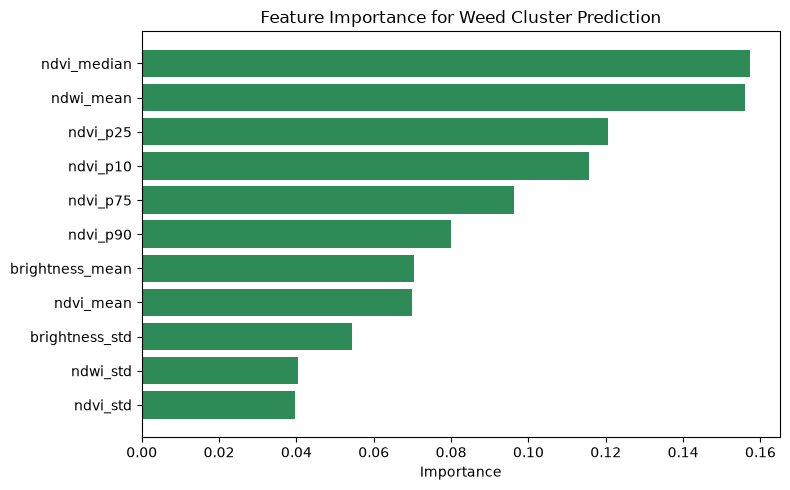

In [19]:
import matplotlib.pyplot as plt

importances = model2.feature_importances_
feat_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(feat_importance_df["feature"], feat_importance_df["importance"], color="seagreen")
plt.xlabel("Importance")
plt.title("Feature Importance for Weed Cluster Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, m in models.items():
    if name == "Logistic Regression":
        m.fit(X_train_scaled, y_train)
        preds = m.predict(X_test_scaled)
    else:
        m.fit(X_train, y_train)
        preds = m.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": classification_report(y_test, preds, output_dict=True)["1"]["precision"],
        "Recall": classification_report(y_test, preds, output_dict=True)["1"]["recall"],
        "F1": classification_report(y_test, preds, output_dict=True)["1"]["f1-score"]
    })

comparison_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print(comparison_df)

                 Model  Accuracy  Precision    Recall        F1
2        Random Forest  0.793478   0.710526  0.771429  0.739726
3    Gradient Boosting  0.750000   0.630435  0.828571  0.716049
0  Logistic Regression  0.663043   0.533333  0.914286  0.673684
1        Decision Tree  0.641304   0.526316  0.571429  0.547945


C:\Users\Gaurav Rajput\OneDrive\Desktop\STUDY MATERIAL\AI Crop Health\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gaurav Rajput\OneDrive\Desktop\STUDY MATERIAL\AI Crop Health\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gaurav Rajput\OneDrive\Desktop\STUDY MATERIAL\AI Crop Health\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Gaurav Rajput\OneDrive\Desktop\STUDY MATERIAL\AI Crop Health\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.wa

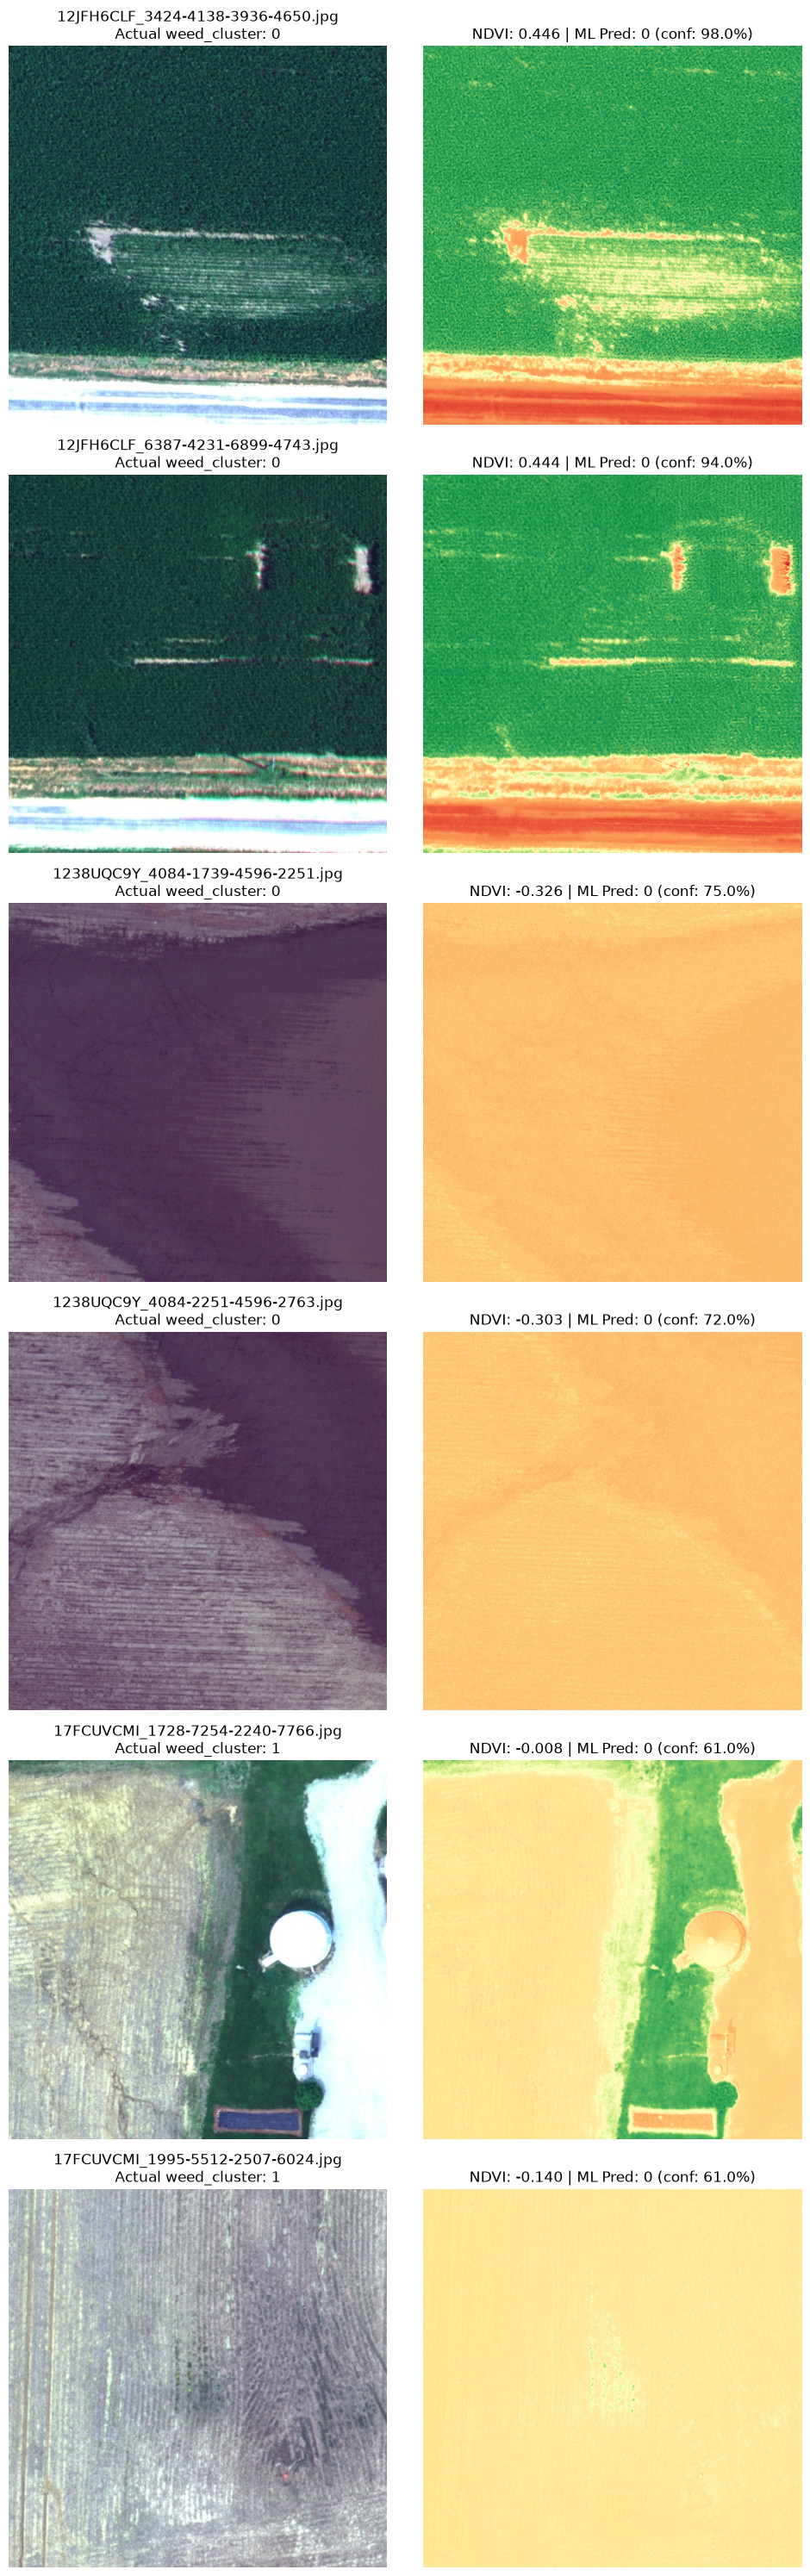

In [21]:
import matplotlib.pyplot as plt

# Pick 6 diverse examples: mix of correct predictions across different NDVI ranges
sample_indices = []

# 2 healthy-looking (high NDVI), 2 stressed (low NDVI), 2 weed-positive
healthy_samples = df_ml2[df_ml2["ndvi_mean"] > 0.3].head(2)
stressed_samples = df_ml2[df_ml2["ndvi_mean"] < -0.1].head(2)
weed_samples = df_ml2[df_ml2["weed_cluster"] == 1].head(2)

showcase_df = pd.concat([healthy_samples, stressed_samples, weed_samples]).drop_duplicates(subset="filename").head(6)

fig, axes = plt.subplots(len(showcase_df), 2, figsize=(10, 5 * len(showcase_df)))

for i, (_, row) in enumerate(showcase_df.iterrows()):
    f = row["filename"]
    rgb_img = cv2.imread(os.path.join(rgb_dir, f))
    rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
    nir_img = cv2.imread(os.path.join(nir_dir, f), cv2.IMREAD_GRAYSCALE)

    red = rgb_img[:, :, 0].astype(float)
    nir_f = nir_img.astype(float)
    ndvi = (nir_f - red) / (nir_f + red + 1e-6)

    features_row = row[feature_cols].values.reshape(1, -1)
    ml_pred = model2.predict(features_row)[0]
    ml_conf = model2.predict_proba(features_row)[0][ml_pred]

    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"{f}\nActual weed_cluster: {row['weed_cluster']}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[i, 1].set_title(f"NDVI: {row['ndvi_mean']:.3f} | ML Pred: {ml_pred} (conf: {ml_conf:.1%})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig("results_showcase.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import os
image_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
for root, dirs, files in os.walk("data2019_miniscale"):
    for f in files:
        if os.path.splitext(f)[1].lower() not in image_exts:
            print(os.path.join(root, f))

data2019_miniscale\field_stats.json
data2019_miniscale\split_stats.json
data2019_miniscale\stats.json


In [24]:
import os
exts = set()
for root, dirs, files in os.walk("data2019_miniscale"):
    for f in files:
        exts.add(os.path.splitext(f)[1].lower())
print(exts)

{'.json', '.png', '.jpg'}


In [25]:
import json

for fname in ["stats.json", "field_stats.json", "split_stats.json"]:
    print(f"--- {fname} ---")
    with open(f"data2019_miniscale/{fname}") as f:
        data = json.load(f)
    print(json.dumps(data, indent=2)[:1000])  # first 1000 chars only
    print()

--- stats.json ---
{
  "image_count": 22627,
  "label_count": {
    "planter_skip": 6274,
    "water": 5108,
    "weed_cluster": 30198,
    "drydown": 0,
    "waterway": 2252,
    "storm_damage": 0,
    "double_plant": 0,
    "nutrient_deficiency": 12067,
    "endrow": 0
  },
  "min_image_size": [
    512,
    512
  ],
  "max_image_size": [
    512,
    512
  ],
  "min_image_area(px^2)": 51,
  "max_image_area(px^2)": 512,
  "avg_image_area(px^2)": 486,
  "max_label_count": {
    "planter_skip": 27,
    "water": 10,
    "weed_cluster": 82,
    "drydown": 0,
    "waterway": 4,
    "storm_damage": 0,
    "double_plant": 0,
    "nutrient_deficiency": 10,
    "endrow": 0
  },
  "avg_label_count": {
    "planter_skip": 0.277,
    "water": 0.226,
    "weed_cluster": 1.335,
    "drydown": 0.0,
    "waterway": 0.1,
    "storm_damage": 0.0,
    "double_plant": 0.0,
    "nutrient_deficiency": 0.533,
    "endrow": 0.0
  },
  "max_label_area(px^2)": {
    "planter_skip": 429,
    "water": 499,
    

In [26]:
import json

with open("data2019_miniscale/field_stats.json") as f:
    field_stats = json.load(f)

# get just the filenames (basenames) from the JSON, from all splits present
json_filenames = set()
for split in field_stats:
    for path in field_stats[split]:
        json_filenames.add(path.split("/")[-1])

# get filenames from your rgb folder
rgb_filenames = set(os.listdir(rgb_dir))

overlap = rgb_filenames & json_filenames
print("Total rgb files:", len(rgb_filenames))
print("Total filenames in field_stats.json:", len(json_filenames))
print("Overlap (matching filenames):", len(overlap))
print("Example overlap:", list(overlap)[:5])

Total rgb files: 22627
Total filenames in field_stats.json: 22627
Overlap (matching filenames): 0
Example overlap: []


In [27]:
print("Sample rgb filenames:")
print(list(rgb_filenames)[:5])

print("\nSample field_stats.json filenames:")
print(list(json_filenames)[:5])


Sample rgb filenames:
['EFFXUYAW9_5312-822-5824-1334.jpg', 'QNPTMGYPC_955-2916-1467-3428.jpg', 'N9EHBNPPL_3485-8232-3997-8744.jpg', 'VCJUGJWMT_6338-9388-6850-9900.jpg', 'VCJUGJWMT_4929-15908-5441-16420.jpg']

Sample field_stats.json filenames:
['LAQC7ZJ8Z_3933-9923-4445-10435.png', '2WXFGL2AU_2483-1160-2995-1672.png', 'EDC73KLBW_3926-1688-4438-2200.png', 'KDWEVLH7Z_2978-2044-3490-2556.png', 'TDYQAEHIC_2499-4961-3011-5473.png']


In [28]:
rgb_basenames = {os.path.splitext(f)[0] for f in rgb_filenames}
json_basenames = {os.path.splitext(f)[0] for f in json_filenames}

overlap2 = rgb_basenames & json_basenames
print("Overlap after removing extensions:", len(overlap2))
print("Example:", list(overlap2)[:5])

Overlap after removing extensions: 22627
Example: ['8ENFEUT7N_11862-5378-12374-5890', 'TKDA22IAV_5012-5598-5524-6110', 'ZRWHRKHZG_2992-6458-3504-6970', 'JB11CWDMY_7533-1159-8045-1671', 'PNT3A28LP_5188-3249-5700-3761']


In [29]:
health_related_labels = ["weed_cluster", "nutrient_deficiency", "drydown", "storm_damage"]

def get_problem_fraction(entry):
    total_problem_area = 0
    for label in health_related_labels:
        areas = entry["label_areas"].get(label, [])
        total_problem_area += sum(areas)
    return total_problem_area / entry["image_area"]

# build a lookup: basename -> problem_fraction
ground_truth = {}
for split in field_stats:
    for path, entry in field_stats[split].items():
        basename = os.path.splitext(path.split("/")[-1])[0]
        ground_truth[basename] = get_problem_fraction(entry)

print("Total ground truth entries:", len(ground_truth))
print("Sample values:", list(ground_truth.items())[:5])

# quick distribution check
gt_series = pd.Series(list(ground_truth.values()))
print("\nProblem fraction stats:")
print(gt_series.describe())

Total ground truth entries: 22627
Sample values: [('Y3RA9WAPY_3892-15459-4404-15971', 0.21179580688476562), ('2L3ZGKHJL_2342-4966-2854-5478', 0.0764617919921875), ('GID71T4G7_2931-3401-3443-3913', 0.3165245056152344), ('Q1PVN4ABJ_2796-16182-3308-16694', 0.5100806451612904), ('VQL2C9LLF_2311-747-2823-1259', 0.0)]

Problem fraction stats:
count    22627.000000
mean         0.175371
std          0.231706
min          0.000000
25%          0.000000
50%          0.067810
75%          0.278353
max          1.034008
dtype: float64


In [30]:
def classify_ground_truth(frac):
    if frac < 0.05:
        return "Healthy"
    elif frac < 0.25:
        return "Moderate"
    else:
        return "Stressed"

# build a small ground-truth dataframe
gt_df = pd.DataFrame([
    {"basename": k, "problem_fraction": v, "gt_health_status": classify_ground_truth(v)}
    for k, v in ground_truth.items()
])

# add basename column to your original df (strip .jpg extension)
df["basename"] = df["filename"].apply(lambda x: os.path.splitext(x)[0])

# merge
merged = df.merge(gt_df, on="basename", how="inner")
print("Merged rows:", len(merged))
print(merged["gt_health_status"].value_counts())
merged.head(10)

Merged rows: 200
gt_health_status
Healthy     190
Moderate     10
Name: count, dtype: int64


,filename,ndvi_mean,health_status,basename,problem_fraction,gt_health_status
0,1238UQC9Y_4084-1739-4596-2251.jpg,-0.326,Stressed,1238UQC9Y_4084-1739-4596-2251,0.0,Healthy
1,1238UQC9Y_4084-2251-4596-2763.jpg,-0.303,Stressed,1238UQC9Y_4084-2251-4596-2763,0.0,Healthy
2,1238UQC9Y_4505-527-5017-1039.jpg,-0.109,Stressed,1238UQC9Y_4505-527-5017-1039,0.0,Healthy
3,1238UQC9Y_4596-1739-5108-2251.jpg,-0.327,Stressed,1238UQC9Y_4596-1739-5108-2251,0.0,Healthy
4,1238UQC9Y_4596-2251-5108-2763.jpg,-0.329,Stressed,1238UQC9Y_4596-2251-5108-2763,0.0,Healthy
5,1238UQC9Y_4889-4243-5401-4755.jpg,-0.273,Stressed,1238UQC9Y_4889-4243-5401-4755,0.0,Healthy
6,1238UQC9Y_5108-1739-5620-2251.jpg,-0.275,Stressed,1238UQC9Y_5108-1739-5620-2251,0.0,Healthy
7,1238UQC9Y_5108-2251-5620-2763.jpg,-0.292,Stressed,1238UQC9Y_5108-2251-5620-2763,0.0,Healthy
8,1238UQC9Y_5401-4243-5913-4755.jpg,-0.290,Stressed,1238UQC9Y_5401-4243-5913-4755,0.0,Healthy
9,12JFH6CLF_3424-4138-3936-4650.jpg,0.446,Healthy,12JFH6CLF_3424-4138-3936-4650,0.0,Healthy
